# BÀI TẬP: PHÂN CỤM DỮ LIỆU K-MEANS & FUZZY C-MEANS (FCM)

**Tập dữ liệu:** Cho 8 sinh viên với tọa độ $(x, y) = (\text{Age}, \text{Marks})$:
$$S_1(5, 10), \quad S_2(6, 8), \quad S_3(4, 5), \quad S_4(7, 10), \quad S_5(8, 12), \quad S_6(10, 9), \quad S_7(12, 11), \quad S_8(4, 6)$$

**Tâm khởi tạo ban đầu:**
$$\mu_1 = C_1 = S_1(5, 10), \quad \mu_2 = C_2 = S_4(7, 10), \quad \mu_3 = C_3 = S_7(12, 11)$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cấu hình matplotlib & pandas: làm tròn 2 chữ số thập phân, không rút gọn bảng
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11

pd.set_option('display.precision', 2)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)
pd.options.display.float_format = '{:.2f}'.format

# Khai báo tọa độ 8 sinh viên
X = np.array([
    [5, 10],  # S1
    [6, 8],   # S2
    [4, 5],   # S3
    [7, 10],  # S4
    [8, 12],  # S5
    [10, 9],  # S6
    [12, 11], # S7
    [4, 6]    # S8
], dtype=float)

student_labels = ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8']

# Tâm khởi tạo ban đầu
initial_centroids = np.array([
    [5.0, 10.0],  # S1
    [7.0, 10.0],  # S4
    [12.0, 11.0]  # S7
], dtype=float)

df_data = pd.DataFrame(X.astype(int), columns=['Age', 'Marks'], index=student_labels)
print("=== TẬP DỮ LIỆU BAN ĐẦU ===")
print(df_data.to_string())
print("\nTâm cụm khởi tạo ban đầu:")
for idx, c in enumerate(initial_centroids, 1):
    print(f" - Cụm {idx}: ({c[0]:.2f}, {c[1]:.2f})")

=== TẬP DỮ LIỆU BAN ĐẦU ===
    Age  Marks
S1    5     10
S2    6      8
S3    4      5
S4    7     10
S5    8     12
S6   10      9
S7   12     11
S8    4      6

Tâm cụm khởi tạo ban đầu:
 - Cụm 1: (5.00, 10.00)
 - Cụm 2: (7.00, 10.00)
 - Cụm 3: (12.00, 11.00)


---
# EXERCISE 01: PRACTICE WITH THE K-MEANS ALGORITHM

### Công thức toán học:
- **Hàm mục tiêu:**
  $$J = \sum_{j=1}^K \sum_{x \in C_j} \|x - \mu_j\|^2$$
- **Khoảng cách Manhattan ($L_1$):**
  $$d_{\text{Manhattan}}(x, \mu) = |x_1 - \mu_1| + |x_2 - \mu_2|$$
- **Khoảng cách Euclidean ($L_2$):**
  $$d_{\text{Euclidean}}(x, \mu) = \sqrt{(x_1 - \mu_1)^2 + (x_2 - \mu_2)^2}$$
- **Cập nhật tâm cụm:**
  $$\mu_j = \frac{1}{|C_j|} \sum_{x \in C_j} x$$

## Câu a: Phân cụm K-Means với khoảng cách Manhattan

Tâm ban đầu: $\mu_1(5.00, 10.00), \mu_2(7.00, 10.00), \mu_3(12.00, 11.00)$.

### 1. Vòng lặp 1 (Iteration 1):
| No | Age | Marks | Dist Mean 1 (5.00, 10.00) | Dist Mean 2 (7.00, 10.00) | Dist Mean 3 (12.00, 11.00) | Cluster |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **S1** | 5 | 10 | **0.00** | 2.00 | 8.00 | **Cluster 1** |
| **S2** | 6 | 8 | **3.00** | **3.00** | 9.00 | **Cluster 1\*** |
| **S3** | 4 | 5 | **6.00** | 8.00 | 14.00 | **Cluster 1** |
| **S4** | 7 | 10 | 2.00 | **0.00** | 6.00 | **Cluster 2** |
| **S5** | 8 | 12 | 5.00 | **3.00** | 5.00 | **Cluster 2** |
| **S6** | 10 | 9 | 6.00 | **4.00** | **4.00** | **Cluster 2\*** |
| **S7** | 12 | 11 | 8.00 | 6.00 | **0.00** | **Cluster 3** |
| **S8** | 4 | 6 | **5.00** | 7.00 | 13.00 | **Cluster 1** |

*(Ghi chú: $S_2$ cách $\mu_1, \mu_2$ cùng bằng 3.00 và $S_6$ cách $\mu_2, \mu_3$ cùng bằng 4.00; áp dụng quy ước ưu tiên chỉ số cụm nhỏ hơn)*

**Cập nhật tâm mới sau Vòng 1:**
- $\mu_1^{(1)} = \text{mean}(S_1, S_2, S_3, S_8) = (4.75, 7.25)$
- $\mu_2^{(1)} = \text{mean}(S_4, S_5, S_6) = (8.33, 10.33)$
- $\mu_3^{(1)} = \text{mean}(S_7) = (12.00, 11.00)$

### 2. Vòng lặp 2 (Iteration 2):
| No | Age | Marks | Dist Mean 1 (4.75, 7.25) | Dist Mean 2 (8.33, 10.33) | Dist Mean 3 (12.00, 11.00) | Cluster |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **S1** | 5 | 10 | **3.00** | 3.67 | 8.00 | **Cluster 1** |
| **S2** | 6 | 8 | **2.00** | 4.67 | 9.00 | **Cluster 1** |
| **S3** | 4 | 5 | **3.00** | 9.67 | 14.00 | **Cluster 1** |
| **S4** | 7 | 10 | 5.00 | **1.67** | 6.00 | **Cluster 2** |
| **S5** | 8 | 12 | 8.00 | **2.00** | 5.00 | **Cluster 2** |
| **S6** | 10 | 9 | 7.00 | **3.00** | 4.00 | **Cluster 2** |
| **S7** | 12 | 11 | 11.00 | 4.33 | **0.00** | **Cluster 3** |
| **S8** | 4 | 6 | **2.00** | 8.67 | 13.00 | **Cluster 1** |

$\implies$ Phân cụm ở Vòng 2 trùng khớp hoàn toàn Vòng 1. **Thuật toán hội tụ sau 2 vòng lặp (Iteration 2).**

In [2]:
# Code thực thi K-Means Manhattan & in các vòng lặp đến khi hội tụ
centroids_manh = initial_centroids.copy()
print("=== THỰC THI K-MEANS (MANHATTAN) ===")

for it in range(1, 10):
    dists = np.abs(X[:, None, :] - centroids_manh[None, :, :]).sum(axis=2)
    clusters = np.argmin(dists, axis=1)
    
    df_iter = pd.DataFrame({
        'No': student_labels,
        'Age': X[:, 0].astype(int),
        'Marks': X[:, 1].astype(int),
        f'Dist Mean 1 ({centroids_manh[0,0]:.2f}, {centroids_manh[0,1]:.2f})': dists[:, 0],
        f'Dist Mean 2 ({centroids_manh[1,0]:.2f}, {centroids_manh[1,1]:.2f})': dists[:, 1],
        f'Dist Mean 3 ({centroids_manh[2,0]:.2f}, {centroids_manh[2,1]:.2f})': dists[:, 2],
        'Cluster': [f'Cluster {c+1}' for c in clusters]
    })
    print(f"\n--- Iteration {it} ---")
    print(df_iter.to_string(index=False))
    
    new_centroids = np.array([X[clusters == c].mean(axis=0) if np.any(clusters == c) else centroids_manh[c] for c in range(3)])
    print(f"\nTâm cụm sau Iteration {it}:")
    for c in range(3):
        pts = [student_labels[i] for i in range(len(X)) if clusters[i] == c]
        print(f" • Cụm {c+1}: {', '.join(pts)} | Tâm cụm: ({new_centroids[c,0]:.2f}, {new_centroids[c,1]:.2f})")
        
    if np.allclose(centroids_manh, new_centroids):
        print(f"\n>> THUẬT TOÁN HỘI TỤ TẠI ITERATION {it}! <<")
        print("KẾT QUẢ PHÂN NHÓM KHI HỘI TỤ (MANHATTAN):")
        for c in range(3):
            pts = [student_labels[i] for i in range(len(X)) if clusters[i] == c]
            print(f" • Cụm {c+1}: {', '.join(pts)} | Tâm cụm: ({new_centroids[c,0]:.2f}, {new_centroids[c,1]:.2f})")
        break
    centroids_manh = new_centroids

=== THỰC THI K-MEANS (MANHATTAN) ===

--- Iteration 1 ---
No  Age  Marks  Dist Mean 1 (5.00, 10.00)  Dist Mean 2 (7.00, 10.00)  Dist Mean 3 (12.00, 11.00)   Cluster
S1    5     10                       0.00                       2.00                        8.00 Cluster 1
S2    6      8                       3.00                       3.00                        9.00 Cluster 1
S3    4      5                       6.00                       8.00                       14.00 Cluster 1
S4    7     10                       2.00                       0.00                        6.00 Cluster 2
S5    8     12                       5.00                       3.00                        5.00 Cluster 2
S6   10      9                       6.00                       4.00                        4.00 Cluster 2
S7   12     11                       8.00                       6.00                        0.00 Cluster 3
S8    4      6                       5.00                       7.00                  

## Câu b: Phân cụm K-Means với khoảng cách Euclidean

Tâm ban đầu: $\mu_1(5.00, 10.00), \mu_2(7.00, 10.00), \mu_3(12.00, 11.00)$.

### 1. Vòng lặp 1 (Iteration 1):
| No | Age | Marks | Dist Mean 1 (5.00, 10.00) | Dist Mean 2 (7.00, 10.00) | Dist Mean 3 (12.00, 11.00) | Cluster |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **S1** | 5 | 10 | **0.00** | 2.00 | 7.07 | **Cluster 1** |
| **S2** | 6 | 8 | **2.24** | **2.24** | 6.71 | **Cluster 1\*** |
| **S3** | 4 | 5 | **5.10** | 5.83 | 10.00 | **Cluster 1** |
| **S4** | 7 | 10 | 2.00 | **0.00** | 5.10 | **Cluster 2** |
| **S5** | 8 | 12 | 3.61 | **2.24** | 4.12 | **Cluster 2** |
| **S6** | 10 | 9 | 5.10 | 3.16 | **2.83** | **Cluster 3** |
| **S7** | 12 | 11 | 7.07 | 5.10 | **0.00** | **Cluster 3** |
| **S8** | 4 | 6 | **4.12** | 5.00 | 9.43 | **Cluster 1** |

> **Thành viên tại Vòng 1:**
> - Cụm 1: $S_1, S_2, S_3, S_8$
> - Cụm 2: $S_4, S_5$
> - Cụm 3: $S_6, S_7$ *(do $d(S_6, \mu_3) = 2.83 < d(S_6, \mu_2) = 3.16$)*

**Cập nhật tâm mới sau Vòng 1:**
- $\mu_1^{(1)} = \text{mean}(S_1, S_2, S_3, S_8) = (4.75, 7.25)$
- $\mu_2^{(1)} = \text{mean}(S_4, S_5) = (7.50, 11.00)$
- $\mu_3^{(1)} = \text{mean}(S_6, S_7) = (11.00, 10.00)$

### 2. Vòng lặp 2 (Iteration 2):
| No | Age | Marks | Dist Mean 1 (4.75, 7.25) | Dist Mean 2 (7.50, 11.00) | Dist Mean 3 (11.00, 10.00) | Cluster |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **S1** | 5 | 10 | 2.76 | **2.69** | 6.00 | **Cluster 2\*\*** |
| **S2** | 6 | 8 | **1.46** | 3.35 | 5.39 | **Cluster 1** |
| **S3** | 4 | 5 | **2.37** | 6.95 | 8.60 | **Cluster 1** |
| **S4** | 7 | 10 | 3.55 | **1.12** | 4.00 | **Cluster 2** |
| **S5** | 8 | 12 | 5.76 | **1.12** | 3.61 | **Cluster 2** |
| **S6** | 10 | 9 | 5.53 | 3.20 | **1.41** | **Cluster 3** |
| **S7** | 12 | 11 | 8.16 | 4.50 | **1.41** | **Cluster 3** |
| **S8** | 4 | 6 | **1.46** | 6.10 | 8.06 | **Cluster 1** |

> **Chuyển cụm tại Vòng 2:**
> - $d(S_1, \mu_1) = \sqrt{(5-4.75)^2 + (10-7.25)^2} = \sqrt{7.625} \approx \mathbf{2.76}$
> - $d(S_1, \mu_2) = \sqrt{(5-7.50)^2 + (10-11.00)^2} = \sqrt{7.250} \approx \mathbf{2.69}$
> - Vì $2.69 < 2.76$, $S_1$ **chuyển từ Cụm 1 sang Cụm 2**. Phân cụm thay đổi nên thuật toán tiếp tục sang Vòng 3.

**Cập nhật tâm mới sau Vòng 2:**
- $\mu_1^{(2)} = \text{mean}(S_2, S_3, S_8) = (4.67, 6.33)$
- $\mu_2^{(2)} = \text{mean}(S_1, S_4, S_5) = (6.67, 10.67)$
- $\mu_3^{(2)} = \text{mean}(S_6, S_7) = (11.00, 10.00)$

### 3. Vòng lặp 3 (Iteration 3):
| No | Age | Marks | Dist Mean 1 (4.67, 6.33) | Dist Mean 2 (6.67, 10.67) | Dist Mean 3 (11.00, 10.00) | Cluster |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **S1** | 5 | 10 | 3.68 | **1.80** | 6.00 | **Cluster 2** |
| **S2** | 6 | 8 | **2.13** | 2.75 | 5.39 | **Cluster 1** |
| **S3** | 4 | 5 | **1.49** | 6.26 | 8.60 | **Cluster 1** |
| **S4** | 7 | 10 | 4.35 | **0.75** | 4.00 | **Cluster 2** |
| **S5** | 8 | 12 | 6.57 | **1.89** | 3.61 | **Cluster 2** |
| **S6** | 10 | 9 | 5.96 | 3.73 | **1.41** | **Cluster 3** |
| **S7** | 12 | 11 | 8.69 | 5.34 | **1.41** | **Cluster 3** |
| **S8** | 4 | 6 | **0.75** | 5.37 | 8.06 | **Cluster 1** |

$\implies$ Phân cụm ở Vòng 3 trùng khớp hoàn toàn Vòng 2. **Thuật toán hội tụ sau 3 vòng lặp (Iteration 3).**

In [3]:
# Code thực thi K-Means Euclidean & in các vòng lặp đến khi hội tụ
centroids_eucl = initial_centroids.copy()
print("=== THỰC THI K-MEANS (EUCLIDEAN) ===")

for it in range(1, 10):
    dists = np.sqrt(np.sum((X[:, None, :] - centroids_eucl[None, :, :])**2, axis=2))
    clusters = np.argmin(dists, axis=1)
    
    df_iter = pd.DataFrame({
        'No': student_labels,
        'Age': X[:, 0].astype(int),
        'Marks': X[:, 1].astype(int),
        f'Dist Mean 1 ({centroids_eucl[0,0]:.2f}, {centroids_eucl[0,1]:.2f})': dists[:, 0],
        f'Dist Mean 2 ({centroids_eucl[1,0]:.2f}, {centroids_eucl[1,1]:.2f})': dists[:, 1],
        f'Dist Mean 3 ({centroids_eucl[2,0]:.2f}, {centroids_eucl[2,1]:.2f})': dists[:, 2],
        'Cluster': [f'Cluster {c+1}' for c in clusters]
    })
    print(f"\n--- Iteration {it} ---")
    print(df_iter.to_string(index=False))
    
    new_centroids = np.array([X[clusters == c].mean(axis=0) if np.any(clusters == c) else centroids_eucl[c] for c in range(3)])
    print(f"\nTâm cụm sau Iteration {it}:")
    for c in range(3):
        pts = [student_labels[i] for i in range(len(X)) if clusters[i] == c]
        print(f" • Cụm {c+1}: {', '.join(pts)} | Tâm cụm: ({new_centroids[c,0]:.2f}, {new_centroids[c,1]:.2f})")
        
    if np.allclose(centroids_eucl, new_centroids):
        print(f"\n>> THUẬT TOÁN HỘI TỤ TẠI ITERATION {it}! <<")
        print("KẾT QUẢ PHÂN NHÓM KHI HỘI TỤ (EUCLIDEAN):")
        for c in range(3):
            pts = [student_labels[i] for i in range(len(X)) if clusters[i] == c]
            print(f" • Cụm {c+1}: {', '.join(pts)} | Tâm cụm: ({new_centroids[c,0]:.2f}, {new_centroids[c,1]:.2f})")
        break
    centroids_eucl = new_centroids

=== THỰC THI K-MEANS (EUCLIDEAN) ===

--- Iteration 1 ---
No  Age  Marks  Dist Mean 1 (5.00, 10.00)  Dist Mean 2 (7.00, 10.00)  Dist Mean 3 (12.00, 11.00)   Cluster
S1    5     10                       0.00                       2.00                        7.07 Cluster 1
S2    6      8                       2.24                       2.24                        6.71 Cluster 1
S3    4      5                       5.10                       5.83                       10.00 Cluster 1
S4    7     10                       2.00                       0.00                        5.10 Cluster 2
S5    8     12                       3.61                       2.24                        4.12 Cluster 2
S6   10      9                       5.10                       3.16                        2.83 Cluster 3
S7   12     11                       7.07                       5.10                        0.00 Cluster 3
S8    4      6                       4.12                       5.00                  

## Câu c: So sánh số vòng lặp hội tụ giữa Manhattan và Euclidean

### Bảng so sánh tổng hợp khi đạt hội tụ:
| Tiêu chí | K-Means (Manhattan) | K-Means (Euclidean) |
|:---|:---:|:---:|
| **Số vòng lặp hội tụ** | **2 vòng lặp** | **3 vòng lặp** |
| **Thành viên Cụm 1** | $S_1, S_2, S_3, S_8$ | $S_2, S_3, S_8$ |
| **Thành viên Cụm 2** | $S_4, S_5, S_6$ | $S_1, S_4, S_5$ |
| **Thành viên Cụm 3** | $S_7$ | $S_6, S_7$ |
| **Tọa độ tâm $\mu_1$** | $(4.75, 7.25)$ | $(4.67, 6.33)$ |
| **Tọa độ tâm $\mu_2$** | $(8.33, 10.33)$ | $(6.67, 10.67)$ |
| **Tọa độ tâm $\mu_3$** | $(12.00, 11.00)$ | $(11.00, 10.00)$ |

### Nhận xét ngắn gọn:
- **Manhattan:** $S_6$ hòa khoảng cách với $\mu_2, \mu_3$, theo quy ước chỉ số nhỏ nên thuộc Cụm 2. Tâm cụm ổn định ngay ở Vòng 2, các điểm không đổi cụm $\implies$ Hội tụ sau **2 vòng lặp**.
- **Euclidean:** $S_6$ gần $\mu_3$ hơn theo đường chéo ($2.83 < 3.16$), nên chuyển sang Cụm 3 từ Vòng 1. Sự dịch chuyển này kéo theo $S_1$ đổi từ Cụm 1 sang Cụm 2 ở Vòng 2 ($2.69 < 2.76$). Do đó thuật toán cần thêm Vòng 3 để xác nhận ổn định $\implies$ Hội tụ sau **3 vòng lặp**.

## Câu d: Cài đặt thuật toán K-Means & Trực quan hóa từng vòng lặp

Với mỗi vòng lặp, hiển thị 2 đồ thị side-by-side:
1. **The clustering result:** Các điểm tô màu theo cụm và tâm cụm hiện tại.
2. **The centroid shift:** Vector mũi tên biểu diễn sự dịch chuyển của từng tâm cụm.

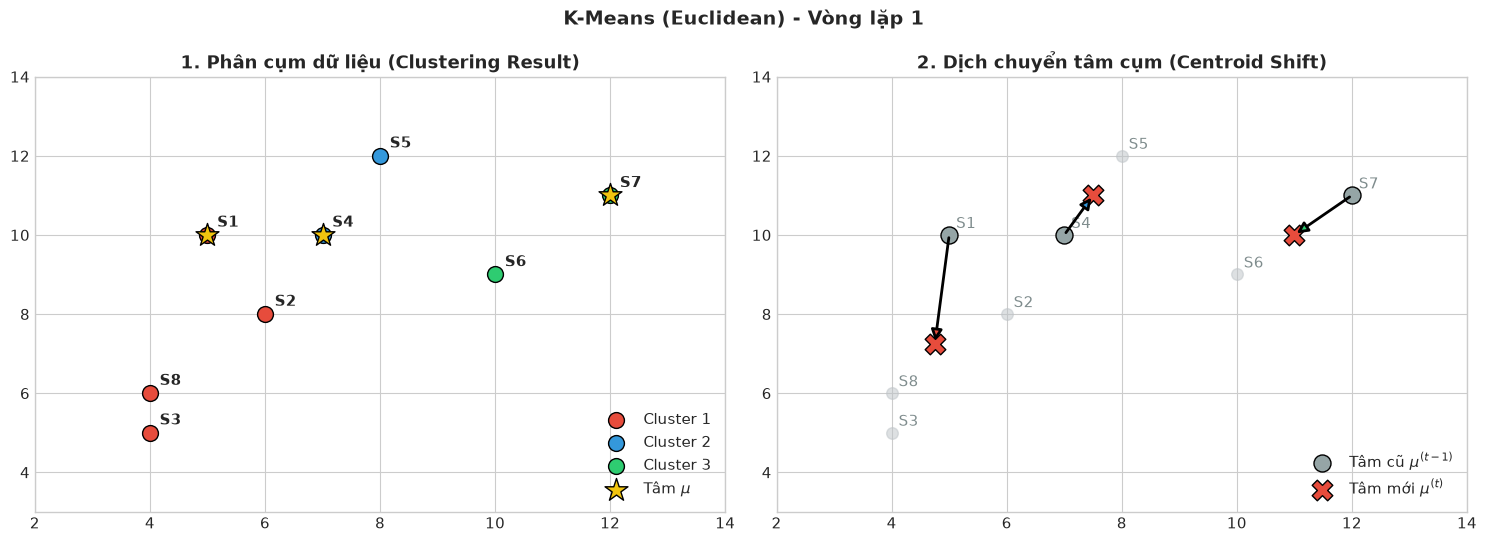

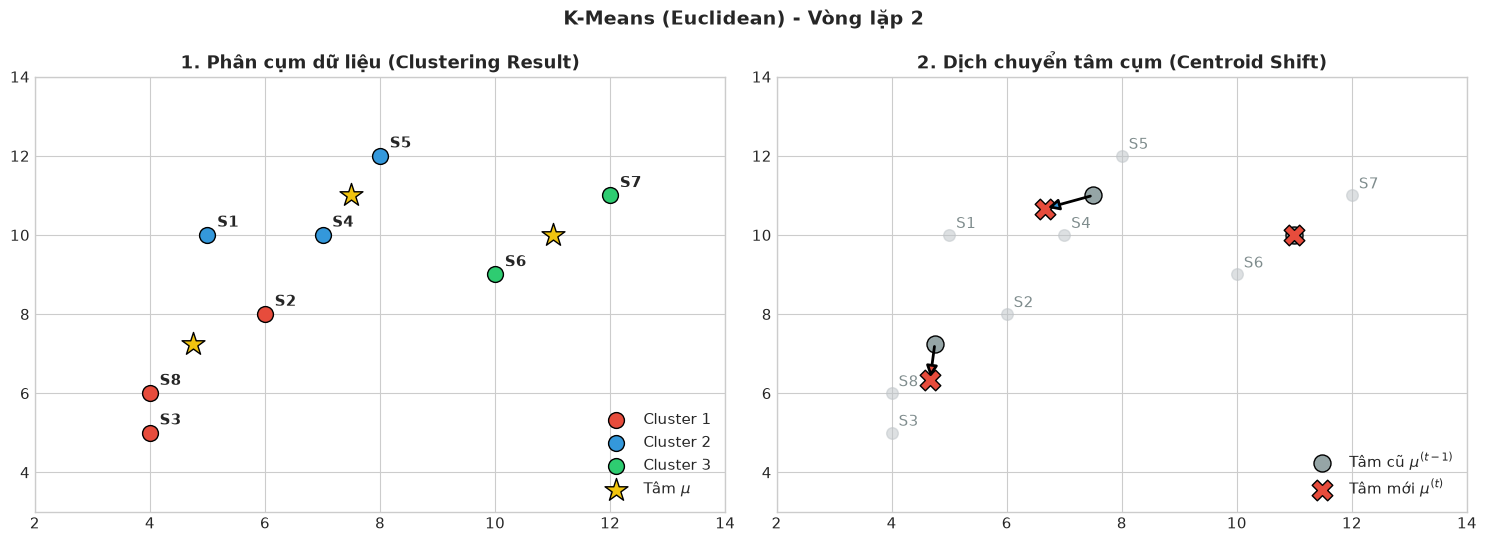

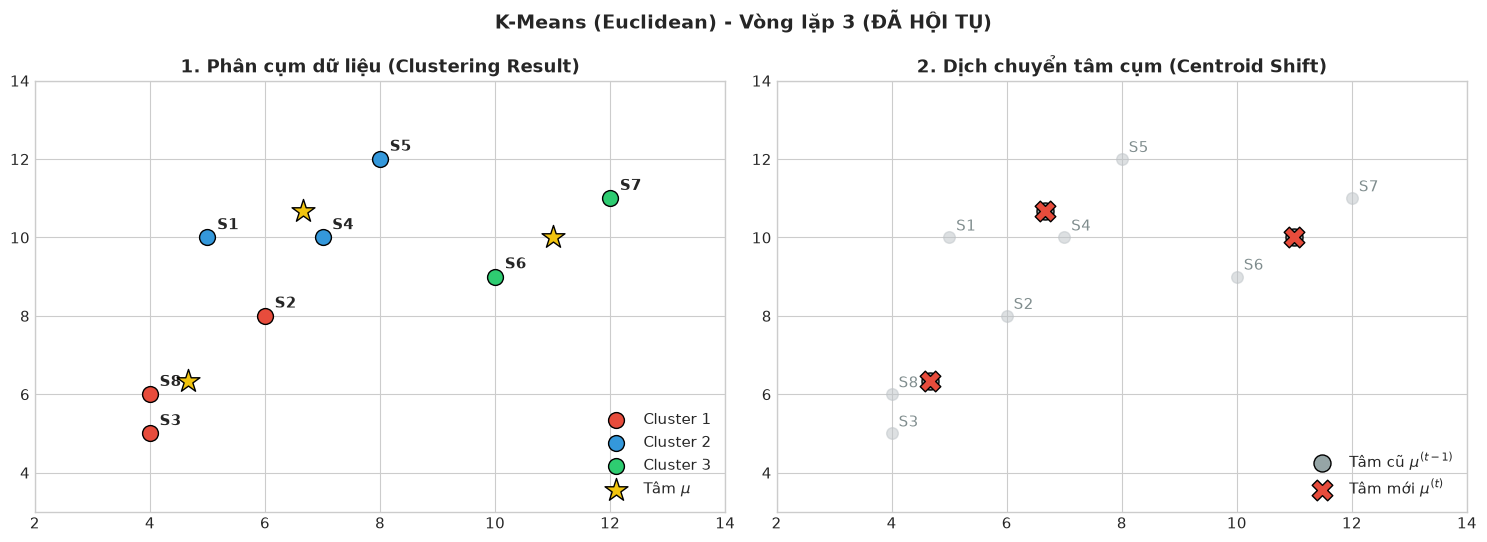

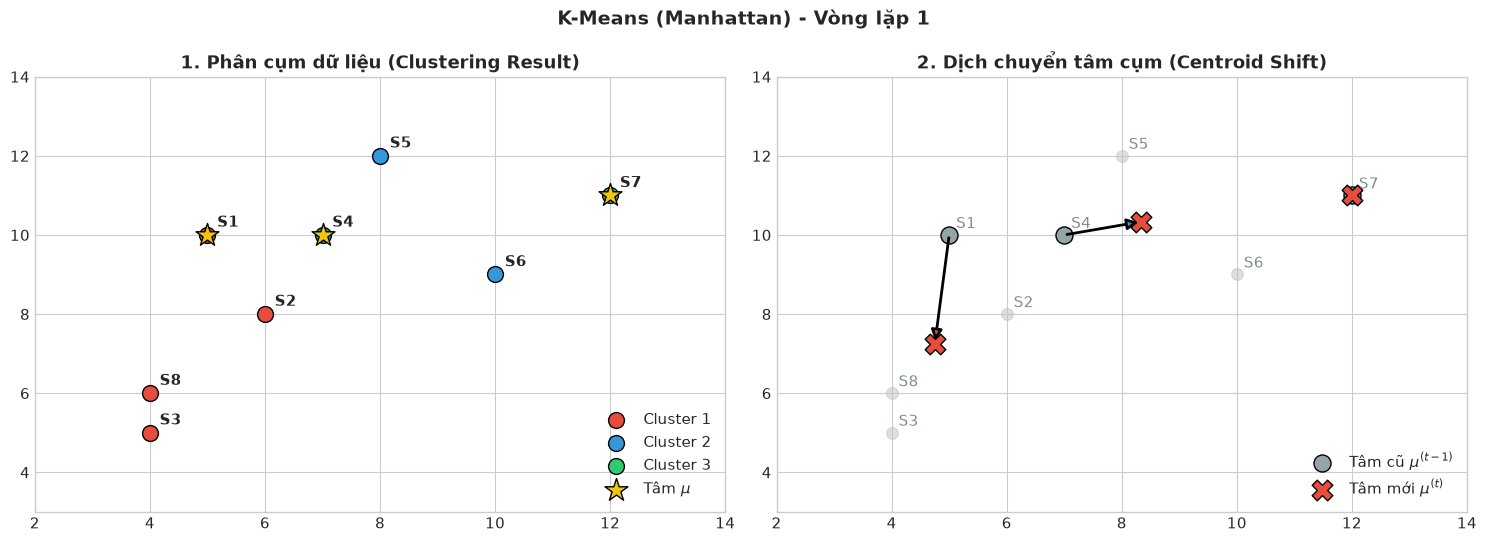

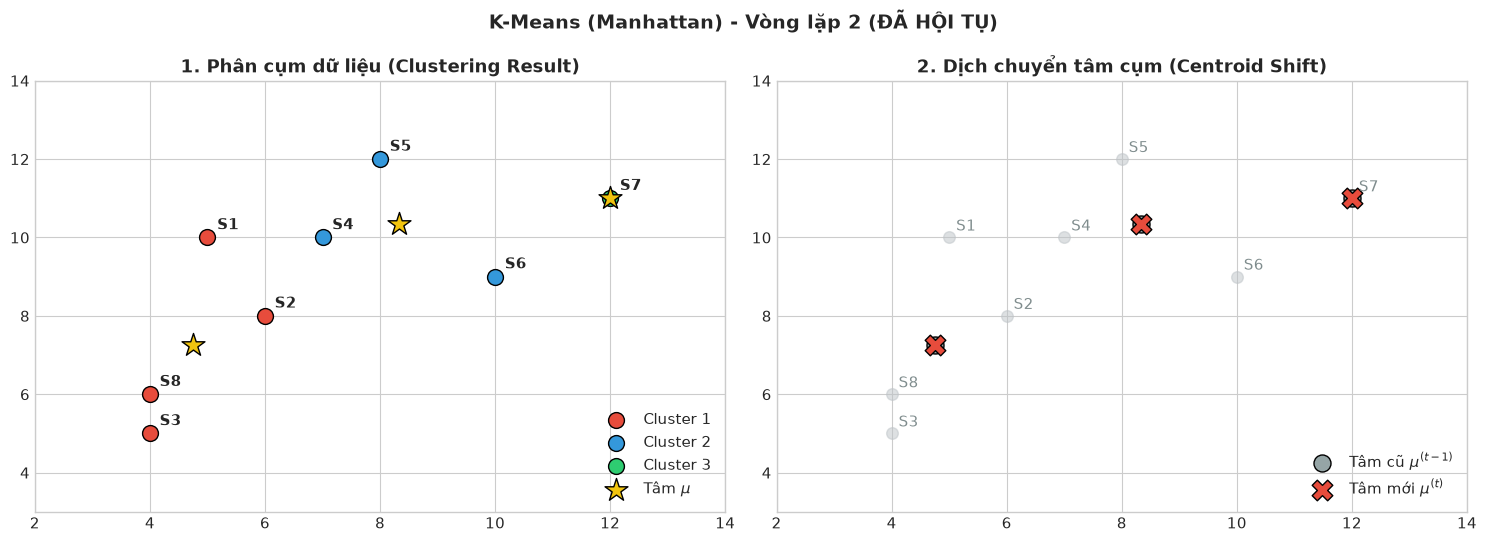

In [4]:
def run_kmeans(X, init_centroids, metric='euclidean', max_iter=10):
    centroids = init_centroids.copy()
    history = []
    for it in range(1, max_iter + 1):
        if metric == 'manhattan':
            dists = np.abs(X[:, None, :] - centroids[None, :, :]).sum(axis=2)
        else:
            dists = np.sqrt(np.sum((X[:, None, :] - centroids[None, :, :])**2, axis=2))
        clusters = np.argmin(dists, axis=1)
        
        new_centroids = np.zeros_like(centroids)
        for c in range(len(centroids)):
            pts = X[clusters == c]
            new_centroids[c] = pts.mean(axis=0) if len(pts) > 0 else centroids[c]
            
        history.append({
            'iteration': it,
            'old_centroids': centroids.copy(),
            'clusters': clusters.copy(),
            'new_centroids': new_centroids.copy(),
            'converged': np.allclose(centroids, new_centroids)
        })
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids.copy()
    return history

def visualize_kmeans_process(X, student_labels, history, metric_name='Euclidean'):
    colors = ['#e74c3c', '#3498db', '#2ecc71']
    for step in history:
        it = step['iteration']
        old_c = step['old_centroids']
        new_c = step['new_centroids']
        clusters = step['clusters']
        
        fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
        fig.suptitle(f"K-Means ({metric_name}) - Vòng lặp {it}" + 
                     (" (ĐÃ HỘI TỤ)" if step['converged'] else ""), fontsize=14, fontweight='bold')
        
        # Plot 1: Clustering Result
        ax1 = axes[0]
        for c_idx in range(len(old_c)):
            mask = (clusters == c_idx)
            if np.any(mask):
                ax1.scatter(X[mask, 0], X[mask, 1], s=130, color=colors[c_idx],
                            edgecolors='k', zorder=3, label=f"Cluster {c_idx+1}")
        for i, lbl in enumerate(student_labels):
            ax1.annotate(lbl, (X[i, 0], X[i, 1]), textcoords="offset points", xytext=(7, 6), fontweight='bold')
        ax1.scatter(old_c[:, 0], old_c[:, 1], color='#f1c40f', s=300, marker='*', edgecolors='k', zorder=5, label=r'Tâm $\mu$')
        ax1.set_title("1. Phân cụm dữ liệu (Clustering Result)", fontweight='bold')
        ax1.set_xlim(2, 14); ax1.set_ylim(3, 14); ax1.legend(loc='lower right')
        
        # Plot 2: Centroid Shift
        ax2 = axes[1]
        ax2.scatter(X[:, 0], X[:, 1], color='#bdc3c7', s=70, alpha=0.5)
        for i, lbl in enumerate(student_labels):
            ax2.annotate(lbl, (X[i, 0], X[i, 1]), textcoords="offset points", xytext=(5, 5), color='#7f8c8d')
        ax2.scatter(old_c[:, 0], old_c[:, 1], color='#95a5a6', s=150, marker='o', edgecolors='k', label=r'Tâm cũ $\mu^{(t-1)}$')
        ax2.scatter(new_c[:, 0], new_c[:, 1], color='#e74c3c', s=220, marker='X', edgecolors='k', label=r'Tâm mới $\mu^{(t)}$')
        for c_idx in range(len(old_c)):
            ax2.annotate('', xy=new_c[c_idx], xytext=old_c[c_idx],
                         arrowprops=dict(facecolor=colors[c_idx], edgecolor='k', arrowstyle="-|>", lw=2, mutation_scale=16))
        ax2.set_title("2. Dịch chuyển tâm cụm (Centroid Shift)", fontweight='bold')
        ax2.set_xlim(2, 14); ax2.set_ylim(3, 14); ax2.legend(loc='lower right')
        
        plt.tight_layout()
        plt.show()

# Trực quan hóa K-Means Euclidean (3 iterations)
history_eucl = run_kmeans(X, initial_centroids, metric='euclidean')
visualize_kmeans_process(X, student_labels, history_eucl, metric_name='Euclidean')

# Trực quan hóa K-Means Manhattan (2 iterations)
history_manh = run_kmeans(X, initial_centroids, metric='manhattan')
visualize_kmeans_process(X, student_labels, history_manh, metric_name='Manhattan')

---
# EXERCISE 02: PRACTICE WITH THE FUZZY C-MEANS (FCM) ALGORITHM

Tập dữ liệu: $S_1, S_2, S_3, S_4, S_5, S_6, S_7, S_8$. Tâm khởi tạo ban đầu: $C_1(5.00, 10.00), C_2(7.00, 10.00), C_3(12.00, 11.00)$. Số cụm $C = 3$, tham số mờ $m = 2$.

### Công thức toán học:
- **Độ thuộc mờ $u_{ij}$ ($m = 2$):**
  $$u_{ij} = \frac{1}{\sum_{l=1}^C \left(\frac{d(x_j, C_i)}{d(x_j, C_l)}\right)^2} = \frac{d(x_j, C_i)^{-2}}{\sum_{l=1}^C d(x_j, C_l)^{-2}}$$
  *(Nếu $d(x_j, C_i) = 0$ thì $u_{ij} = 1.00$ và $u_{lj} = 0.00$ với mọi $l \neq i$)*
- **Cập nhật tâm cụm $C_i$:**
  $$C_i = \frac{\sum_{j=1}^N u_{ij}^2 x_j}{\sum_{j=1}^N u_{ij}^2}$$
- **Điều kiện dừng:**
  $$\max_{i} \|C_i^{(k)} - C_i^{(k-1)}\| < \epsilon = 10^{-1} = 0.10 \quad \text{hoặc tối đa 20 vòng lặp}$$

## Câu a: Thực hiện thuật toán Fuzzy C-Means từng bước cho 3 vòng lặp đầu tiên

### 1. VÒNG LẶP 1 (ITERATION 1):
**Distance & Membership Computation:**
| No | Age | Marks | Dist to C1 | Dist to C2 | Dist to C3 | $\mu_1$ (Cluster 1) | $\mu_2$ (Cluster 2) | $\mu_3$ (Cluster 3) | $\sum \mu$ |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **S1** | 5 | 10 | 0.00 | 2.00 | 7.07 | **1.00** | 0.00 | 0.00 | 1.00 |
| **S2** | 6 | 8 | 2.24 | 2.24 | 6.71 | **0.47** | **0.47** | 0.05 | 1.00 |
| **S3** | 4 | 5 | 5.10 | 5.83 | 10.00 | **0.49** | 0.38 | 0.13 | 1.00 |
| **S4** | 7 | 10 | 2.00 | 0.00 | 5.10 | 0.00 | **1.00** | 0.00 | 1.00 |
| **S5** | 8 | 12 | 3.61 | 2.24 | 4.12 | 0.23 | **0.60** | 0.18 | 1.00 |
| **S6** | 10 | 9 | 5.10 | 3.16 | 2.83 | 0.15 | 0.38 | **0.47** | 1.00 |
| **S7** | 12 | 11 | 7.07 | 5.10 | 0.00 | 0.00 | 0.00 | **1.00** | 1.00 |
| **S8** | 4 | 6 | 4.12 | 5.00 | 9.43 | **0.53** | 0.36 | 0.10 | 1.00 |

**Cluster Centroid Update:**
| Centroid | Old Coordinates | Updated Coordinates | Shift |
|:---:|:---:|:---:|:---:|
| **C1** | (5.00, 10.00) | **(4.98, 8.51)** | 1.49 |
| **C2** | (7.00, 10.00) | **(6.87, 9.44)** | 0.58 |
| **C3** | (12.00, 11.00) | **(11.37, 10.55)** | 0.77 |
*(Max Shift = 1.49 > 0.10 $\implies$ Tiếp tục sang Vòng 2)*

---
### 2. VÒNG LẶP 2 (ITERATION 2):
**Distance & Membership Computation:**
| No | Age | Marks | Dist to C1 | Dist to C2 | Dist to C3 | $\mu_1$ (Cluster 1) | $\mu_2$ (Cluster 2) | $\mu_3$ (Cluster 3) | $\sum \mu$ |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **S1** | 5 | 10 | 1.49 | 1.95 | 6.40 | **0.61** | 0.36 | 0.03 | 1.00 |
| **S2** | 6 | 8 | 1.14 | 1.68 | 5.95 | **0.67** | 0.31 | 0.02 | 1.00 |
| **S3** | 4 | 5 | 3.64 | 5.28 | 9.23 | **0.61** | 0.29 | 0.10 | 1.00 |
| **S4** | 7 | 10 | 2.51 | 0.58 | 4.41 | 0.05 | **0.93** | 0.02 | 1.00 |
| **S5** | 8 | 12 | 4.62 | 2.80 | 3.67 | 0.19 | **0.51** | 0.30 | 1.00 |
| **S6** | 10 | 9 | 5.05 | 3.16 | 2.07 | 0.11 | 0.27 | **0.63** | 1.00 |
| **S7** | 12 | 11 | 7.45 | 5.36 | 0.77 | 0.01 | 0.02 | **0.97** | 1.00 |
| **S8** | 4 | 6 | 2.69 | 4.48 | 8.66 | **0.69** | 0.25 | 0.07 | 1.00 |

**Cluster Centroid Update:**
| Centroid | Old Coordinates | Updated Coordinates | Shift |
|:---:|:---:|:---:|:---:|
| **C1** | (4.98, 8.51) | **(4.86, 7.32)** | 1.19 |
| **C2** | (6.87, 9.44) | **(6.81, 9.74)** | 0.31 |
| **C3** | (11.37, 10.55) | **(11.12, 10.46)** | 0.27 |
*(Max Shift = 1.19 > 0.10 $\implies$ Tiếp tục sang Vòng 3)*

---
### 3. VÒNG LẶP 3 (ITERATION 3):
**Distance & Membership Computation:**
| No | Age | Marks | Dist to C1 | Dist to C2 | Dist to C3 | $\mu_1$ (Cluster 1) | $\mu_2$ (Cluster 2) | $\mu_3$ (Cluster 3) | $\sum \mu$ |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **S1** | 5 | 10 | 2.68 | 1.82 | 6.14 | 0.30 | **0.65** | 0.06 | 1.00 |
| **S2** | 6 | 8 | 1.32 | 1.92 | 5.68 | **0.65** | 0.31 | 0.04 | 1.00 |
| **S3** | 4 | 5 | 2.48 | 5.51 | 8.98 | **0.78** | 0.16 | 0.06 | 1.00 |
| **S4** | 7 | 10 | 3.43 | 0.32 | 4.15 | 0.01 | **0.99** | 0.01 | 1.00 |
| **S5** | 8 | 12 | 5.63 | 2.55 | 3.48 | 0.12 | **0.57** | 0.31 | 1.00 |
| **S6** | 10 | 9 | 5.40 | 3.28 | 1.84 | 0.08 | 0.22 | **0.70** | 1.00 |
| **S7** | 12 | 11 | 8.03 | 5.34 | 1.03 | 0.02 | 0.04 | **0.95** | 1.00 |
| **S8** | 4 | 6 | 1.58 | 4.68 | 8.40 | **0.87** | 0.10 | 0.03 | 1.00 |

**Cluster Centroid Update:**
| Centroid | Old Coordinates | Updated Coordinates | Shift |
|:---:|:---:|:---:|:---:|
| **C1** | (4.86, 7.32) | **(4.55, 6.37)** | 1.00 |
| **C2** | (6.81, 9.74) | **(6.71, 10.13)** | 0.40 |
| **C3** | (11.12, 10.46) | **(11.05, 10.39)** | 0.10 |
*(Max Shift = 1.00 > 0.10 $\implies$ Tiếp tục lặp đến khi hội tụ)*

In [5]:
# Code thực thi Fuzzy C-Means cho 3 vòng lặp đầu tiên
def compute_fcm_step(X, C, m=2.0):
    N, num_c = len(X), len(C)
    dists = np.zeros((N, num_c))
    U = np.zeros((N, num_c))
    for j in range(N):
        for i in range(num_c):
            dists[j, i] = np.linalg.norm(X[j] - C[i])
        zeros = np.where(dists[j] == 0)[0]
        if len(zeros) > 0:
            U[j, :] = 0.0
            U[j, zeros[0]] = 1.0
        else:
            inv_d2 = 1.0 / (dists[j] ** (2.0 / (m - 1.0)))
            U[j, :] = inv_d2 / np.sum(inv_d2)
    new_C = np.zeros_like(C)
    for i in range(num_c):
        weights = U[:, i] ** m
        new_C[i] = np.sum(weights[:, None] * X, axis=0) / np.sum(weights)
    return dists, U, new_C

C_fcm = initial_centroids.copy()
print("=== THỰC THI FUZZY C-MEANS (3 VÒNG LẶP ĐẦU TIÊN) ===")

for it in range(1, 4):
    dists, U, new_C = compute_fcm_step(X, C_fcm, m=2.0)
    shifts = np.linalg.norm(new_C - C_fcm, axis=1)
    
    df_d = pd.DataFrame({
        'No': student_labels,
        'Age': X[:, 0].astype(int),
        'Marks': X[:, 1].astype(int),
        'Dist to C1': dists[:, 0],
        'Dist to C2': dists[:, 1],
        'Dist to C3': dists[:, 2],
        'mu1 (Cluster 1)': U[:, 0],
        'mu2 (Cluster 2)': U[:, 1],
        'mu3 (Cluster 3)': U[:, 2],
        'sum(mu)': U.sum(axis=1)
    })
    
    df_c = pd.DataFrame({
        'Centroid': ['C1', 'C2', 'C3'],
        'Old Coordinates': [f"({C_fcm[i,0]:.2f}, {C_fcm[i,1]:.2f})" for i in range(3)],
        'Updated Coordinates': [f"({new_C[i,0]:.2f}, {new_C[i,1]:.2f})" for i in range(3)],
        'Shift': shifts
    })
    
    print(f"\n--- FCM ITERATION {it} ---")
    print("1. Bảng Distance & Membership:")
    print(df_d.to_string(index=False))
    print("\n2. Bảng Cập nhật Tâm cụm:")
    print(df_c.to_string(index=False))
    print(f">> Max Shift = {np.max(shifts):.2f}")
    
    C_fcm = new_C

=== THỰC THI FUZZY C-MEANS (3 VÒNG LẶP ĐẦU TIÊN) ===

--- FCM ITERATION 1 ---
1. Bảng Distance & Membership:
No  Age  Marks  Dist to C1  Dist to C2  Dist to C3  mu1 (Cluster 1)  mu2 (Cluster 2)  mu3 (Cluster 3)  sum(mu)
S1    5     10        0.00        2.00        7.07             1.00             0.00             0.00     1.00
S2    6      8        2.24        2.24        6.71             0.47             0.47             0.05     1.00
S3    4      5        5.10        5.83       10.00             0.49             0.38             0.13     1.00
S4    7     10        2.00        0.00        5.10             0.00             1.00             0.00     1.00
S5    8     12        3.61        2.24        4.12             0.23             0.60             0.18     1.00
S6   10      9        5.10        3.16        2.83             0.15             0.38             0.47     1.00
S7   12     11        7.07        5.10        0.00             0.00             0.00             1.00     1.00
S8 

## Câu b: Cài đặt thuật toán Fuzzy C-Means và Trực quan hóa từng vòng lặp

Tiêu chuẩn dừng: $\epsilon = 10^{-1} = 0.10$ hoặc tối đa 20 vòng lặp.

Với mỗi vòng lặp, hiển thị 2 đồ thị side-by-side:
1. **The soft clustering result:** Độ thuộc mờ biểu diễn bằng phối màu liên tục RGB pha trộn từ $(u_1, u_2, u_3)$ và tâm cụm hiện tại.
2. **The centroid shift:** Vector mũi tên biểu diễn sự dịch chuyển của từng tâm cụm.

>> THUẬT TOÁN FCM HỘI TỤ SAU 6 VÒNG LẶP (eps = 0.10) <<
KẾT QUẢ PHÂN NHÓM KHI HỘI TỤ (theo độ thuộc cao nhất):
 • Cụm 1: S3, S8 | Tâm cụm: (4.12, 5.68)
 • Cụm 2: S1, S2, S4, S5 | Tâm cụm: (6.47, 10.03)
 • Cụm 3: S6, S7 | Tâm cụm: (10.93, 10.25)


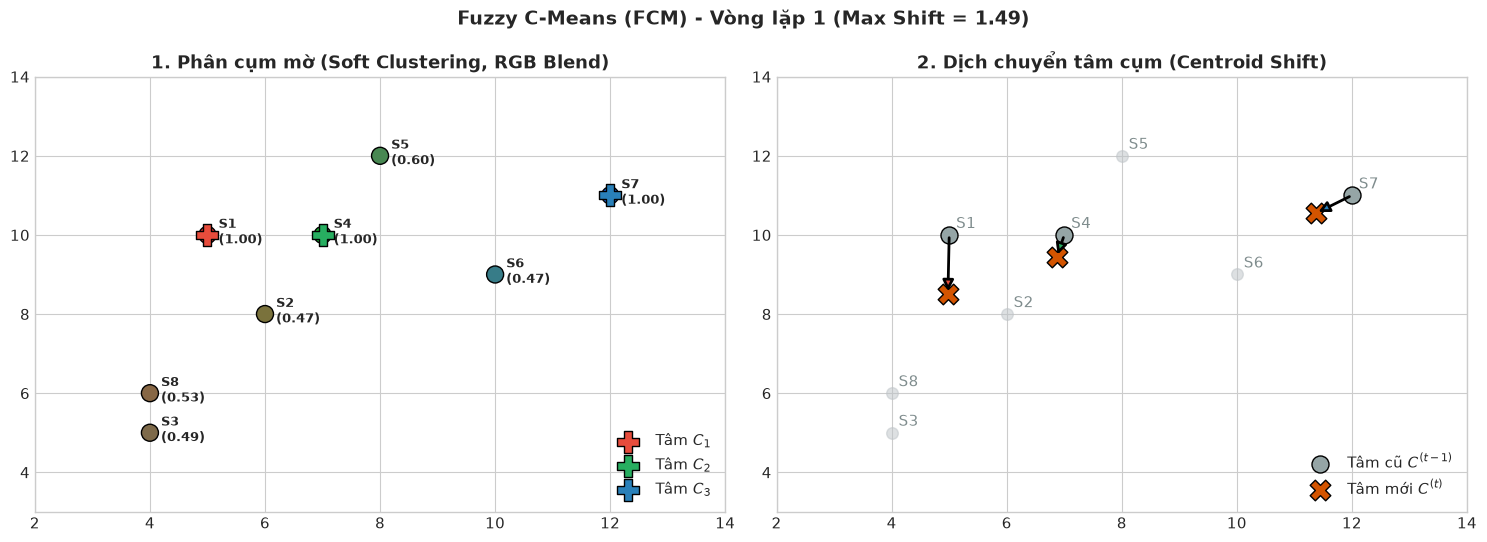

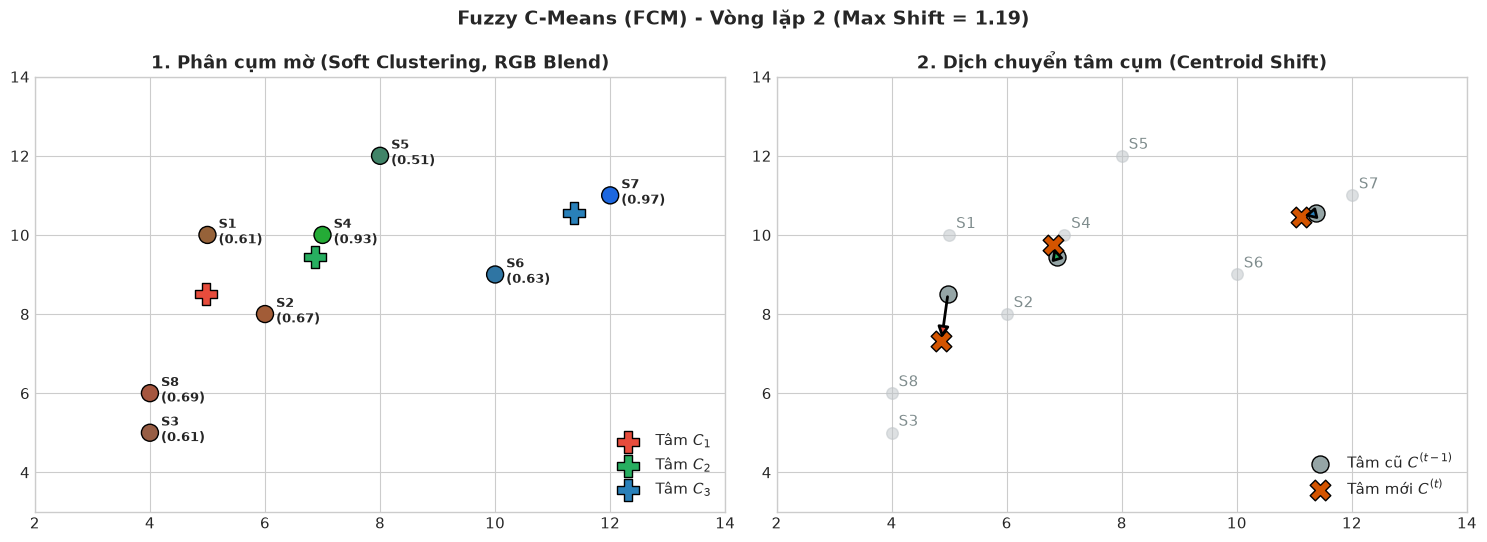

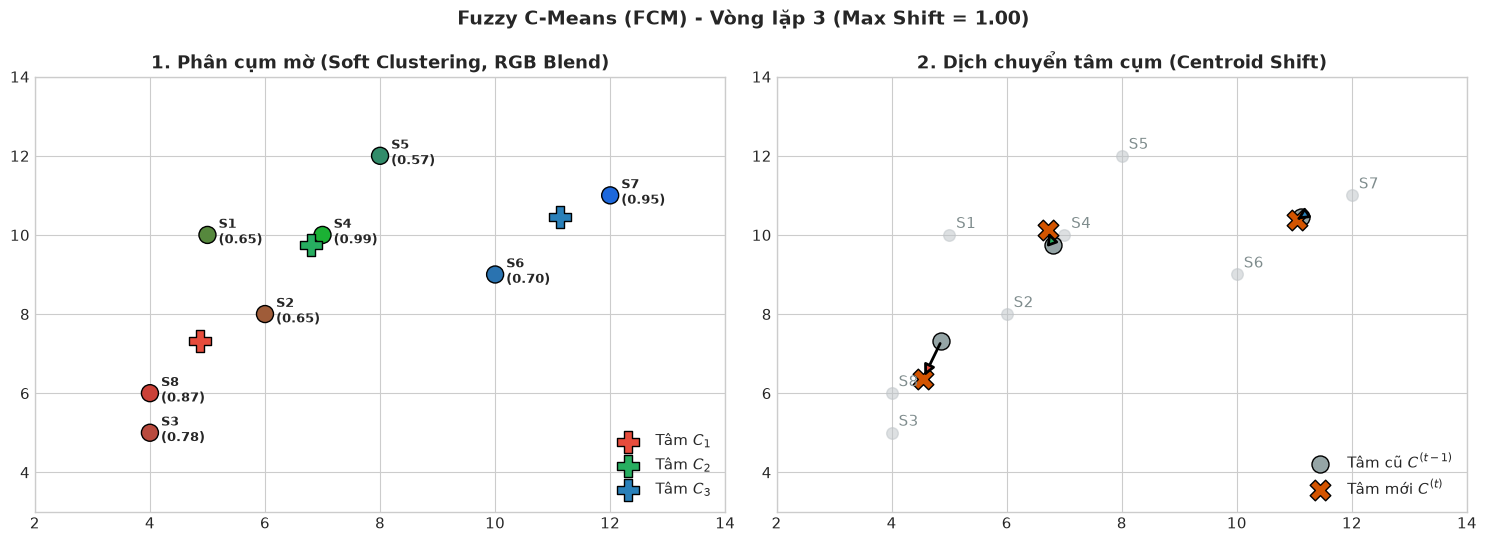

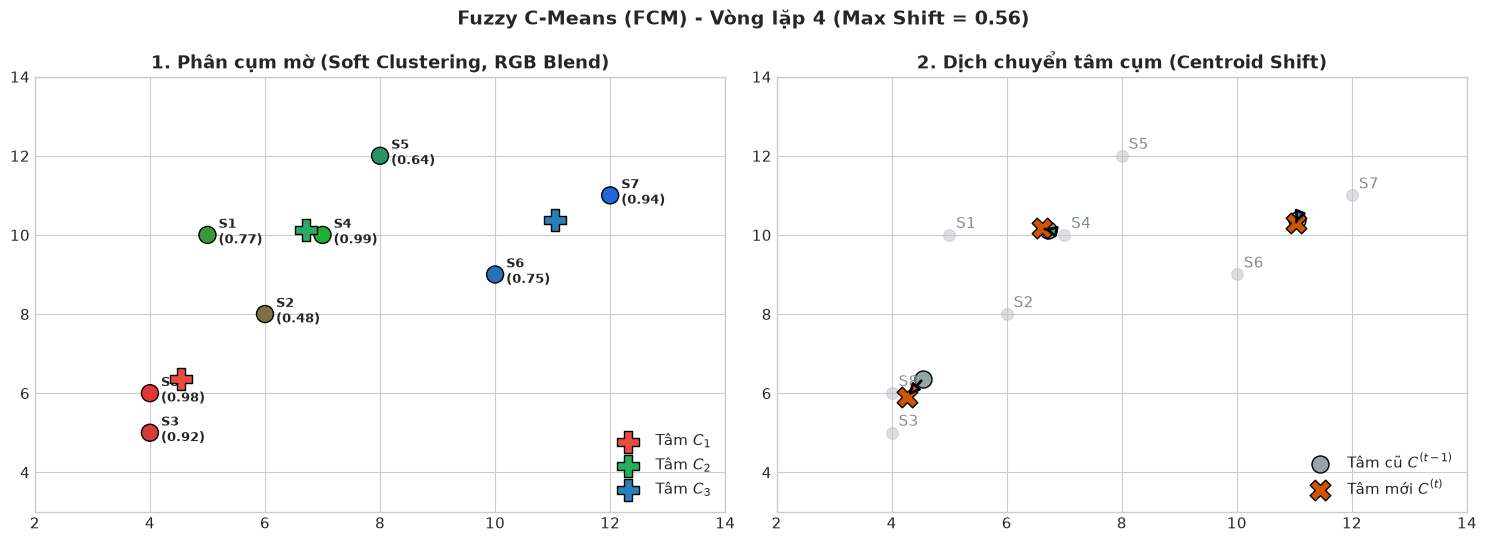

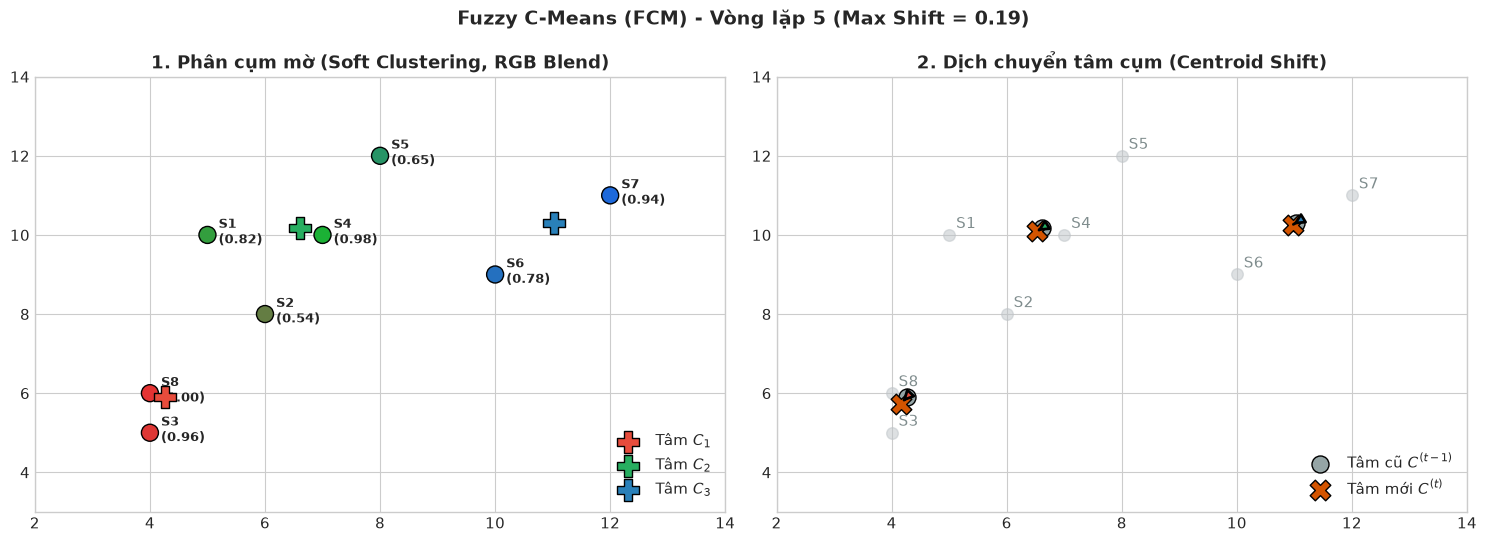

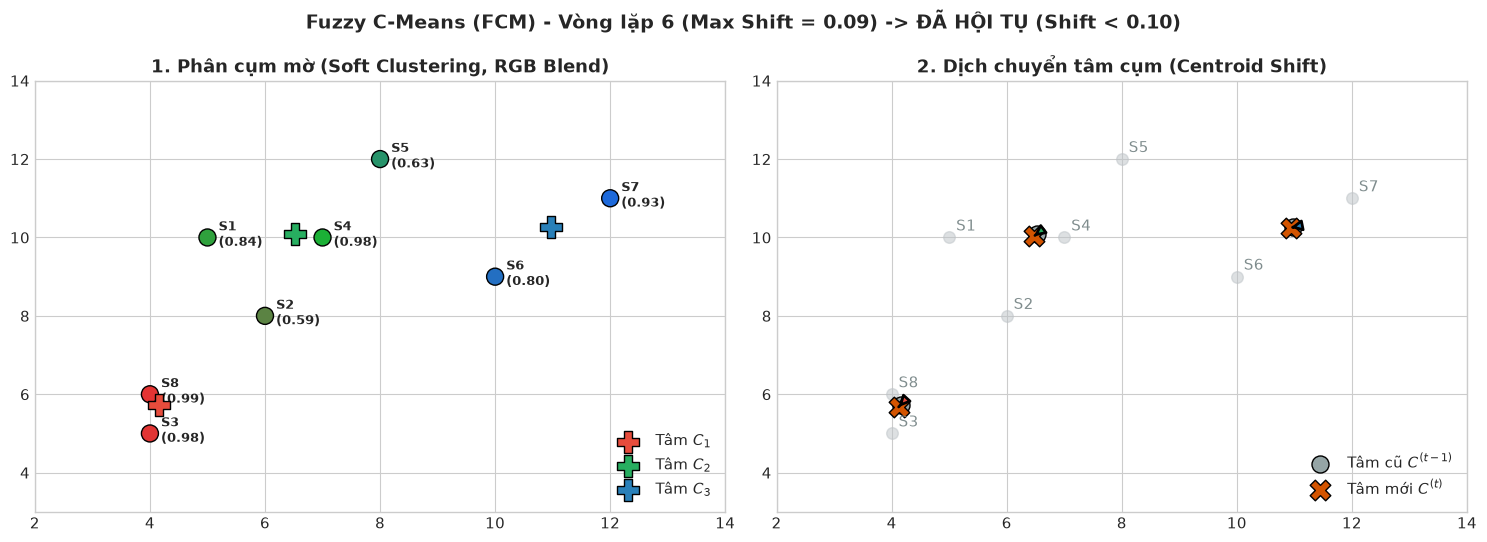

In [6]:
def run_fuzzy_c_means(X, init_centers, m=2.0, eps=0.1, max_iter=20):
    C = init_centers.copy()
    history = []
    for it in range(1, max_iter + 1):
        dists, U, new_C = compute_fcm_step(X, C, m=m)
        shifts = np.linalg.norm(new_C - C, axis=1)
        max_shift = np.max(shifts)
        converged = (max_shift < eps)
        
        history.append({
            'iteration': it,
            'old_centers': C.copy(),
            'U': U.copy(),
            'new_centers': new_C.copy(),
            'shifts': shifts.copy(),
            'max_shift': max_shift,
            'converged': converged
        })
        C = new_C.copy()
        if converged:
            break
    return history

def visualize_fcm_process(X, student_labels, history):
    centroid_colors = ['#e74c3c', '#27ae60', '#2980b9']
    cluster_base_rgb = np.array([
        [0.9, 0.2, 0.2],  # C1 Đỏ
        [0.1, 0.7, 0.2],  # C2 Xanh lá
        [0.1, 0.4, 0.9]   # C3 Xanh dương
    ])
    
    for step in history:
        it = step['iteration']
        old_c = step['old_centers']
        new_c = step['new_centers']
        U = step['U']
        shifts = step['shifts']
        
        fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
        fig.suptitle(f"Fuzzy C-Means (FCM) - Vòng lặp {it} (Max Shift = {step['max_shift']:.2f})" + 
                     (" -> ĐÃ HỘI TỤ (Shift < 0.10)" if step['converged'] else ""), 
                     fontsize=14, fontweight='bold')
        
        # 1. Soft clustering
        ax1 = axes[0]
        point_colors = np.clip(U @ cluster_base_rgb, 0, 1)
        ax1.scatter(X[:, 0], X[:, 1], color=point_colors, s=150, edgecolors='k', zorder=4)
        for i, lbl in enumerate(student_labels):
            ax1.annotate(f"{lbl}\n({np.max(U[i]):.2f})", (X[i, 0], X[i, 1]), 
                         textcoords="offset points", xytext=(8, -6), fontsize=9, fontweight='bold')
        for c_idx in range(len(old_c)):
            ax1.scatter(old_c[c_idx, 0], old_c[c_idx, 1], color=centroid_colors[c_idx],
                        s=250, marker='P', edgecolors='k', zorder=6, label=f"Tâm $C_{c_idx+1}$")
        ax1.set_title("1. Phân cụm mờ (Soft Clustering, RGB Blend)", fontweight='bold')
        ax1.set_xlim(2, 14); ax1.set_ylim(3, 14); ax1.legend(loc='lower right')
        
        # 2. Centroid shift
        ax2 = axes[1]
        ax2.scatter(X[:, 0], X[:, 1], color='#bdc3c7', s=70, alpha=0.5)
        for i, lbl in enumerate(student_labels):
            ax2.annotate(lbl, (X[i, 0], X[i, 1]), textcoords="offset points", xytext=(5, 5), color='#7f8c8d')
        ax2.scatter(old_c[:, 0], old_c[:, 1], color='#95a5a6', s=150, marker='o', edgecolors='k', label=r'Tâm cũ $C^{(t-1)}$')
        ax2.scatter(new_c[:, 0], new_c[:, 1], color='#d35400', s=220, marker='X', edgecolors='k', label=r'Tâm mới $C^{(t)}$')
        for c_idx in range(len(old_c)):
            ax2.annotate('', xy=new_c[c_idx], xytext=old_c[c_idx],
                         arrowprops=dict(facecolor=centroid_colors[c_idx], edgecolor='k', arrowstyle="-|>", lw=2, mutation_scale=16))
        ax2.set_title("2. Dịch chuyển tâm cụm (Centroid Shift)", fontweight='bold')
        ax2.set_xlim(2, 14); ax2.set_ylim(3, 14); ax2.legend(loc='lower right')
        
        plt.tight_layout()
        plt.show()

# Thực thi và vẽ đồ thị
fcm_history = run_fuzzy_c_means(X, initial_centroids, m=2.0, eps=0.1, max_iter=20)
print(f">> THUẬT TOÁN FCM HỘI TỤ SAU {len(fcm_history)} VÒNG LẶP (eps = 0.10) <<")
print("KẾT QUẢ PHÂN NHÓM KHI HỘI TỤ (theo độ thuộc cao nhất):")
final_U = fcm_history[-1]['U']
final_C = fcm_history[-1]['new_centers']
for c in range(3):
    hard_members = [student_labels[i] for i in range(len(X)) if np.argmax(final_U[i]) == c]
    print(f" • Cụm {c+1}: {', '.join(hard_members)} | Tâm cụm: ({final_C[c,0]:.2f}, {final_C[c,1]:.2f})")

visualize_fcm_process(X, student_labels, fcm_history)

## Câu c: So sánh hiệu năng và kết quả giữa K-Means và Fuzzy C-Means

### 1. Điểm ranh giới (Boundary points) & Phân cụm mềm vs cứng:
- **$S_2(6, 8)$:** Nằm ở vùng biên giữa Cụm 1 và Cụm 2. K-Means gán cứng 100% vào Cụm 1. FCM phản ánh tính mềm dẻo với độ thuộc: $\mu_1 \approx 0.65, \mu_2 \approx 0.31, \mu_3 \approx 0.04$.
- **$S_1(5, 10)$:** Trong K-Means Euclidean, $S_1$ bị nhảy cụm đột ngột từ C1 sang C2. Trong FCM, độ thuộc dịch chuyển mượt mà ($\mu_1: 1.00 \to 0.61 \to 0.30 \to 0.28$).
- **$S_6(10, 9)$:** Nằm giữa Cụm 2 và Cụm 3. FCM phân chia độ thuộc liên tục: $\mu_2 \approx 0.20, \mu_3 \approx 0.74$.

### 2. Tốc độ hội tụ:
- **K-Means (Manhattan: 2 vòng, Euclidean: 3 vòng):** Hội tụ rất nhanh vì không gian gán nhãn rời rạc đạt trạng thái dừng cục bộ.
- **FCM (6 vòng lặp với $\epsilon = 0.10$):** Cần nhiều vòng lặp hơn vì không gian liên tục $[0, 1]^{C \times N}$, tâm dịch chuyển tiệm cận mượt mà.

### 3. Tọa độ tâm cụm cuối cùng:
- K-Means tính trung bình số học đơn thuần (trọng số 1 cho điểm trong cụm, 0 cho điểm ngoài cụm).
- FCM tính trung bình trọng số mũ $(u_{ij})^2$, giúp tâm cụm tập trung chặt vào mật độ lõi của cụm và ít bị ảnh hưởng bởi điểm ngoại vi.

=== BẢNG ĐỐI CHIẾU TÂM CỤM CUỐI CÙNG ===
Centroid K-Means (Manhattan) K-Means (Euclidean)  Fuzzy C-Means
   Cụm 1        (4.75, 7.25)        (4.67, 6.33)   (4.12, 5.68)
   Cụm 2       (8.33, 10.33)       (6.67, 10.67)  (6.47, 10.03)
   Cụm 3      (12.00, 11.00)      (11.00, 10.00) (10.93, 10.25)


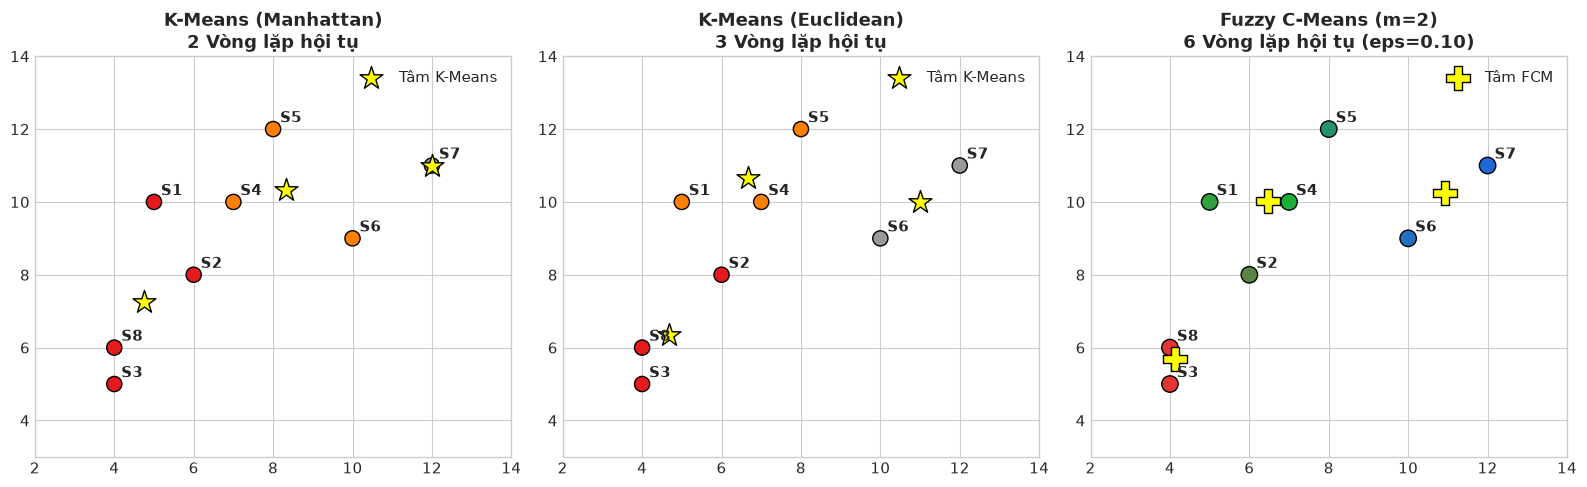

In [7]:
# Bảng đối chiếu tọa độ tâm cụm cuối cùng & trực quan hóa so sánh
final_cent_manh = history_manh[-1]['new_centroids']
final_cent_eucl = history_eucl[-1]['new_centroids']
final_cent_fcm = fcm_history[-1]['new_centers']

df_compare = pd.DataFrame({
    'Centroid': ['Cụm 1', 'Cụm 2', 'Cụm 3'],
    'K-Means (Manhattan)': [f"({final_cent_manh[i,0]:.2f}, {final_cent_manh[i,1]:.2f})" for i in range(3)],
    'K-Means (Euclidean)': [f"({final_cent_eucl[i,0]:.2f}, {final_cent_eucl[i,1]:.2f})" for i in range(3)],
    'Fuzzy C-Means': [f"({final_cent_fcm[i,0]:.2f}, {final_cent_fcm[i,1]:.2f})" for i in range(3)]
})
print("=== BẢNG ĐỐI CHIẾU TÂM CỤM CUỐI CÙNG ===")
print(df_compare.to_string(index=False))

# Đồ thị so sánh 3 phương pháp
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. K-Means Manhattan
axes[0].scatter(X[:, 0], X[:, 1], c=history_manh[-1]['clusters'], cmap='Set1', s=120, edgecolors='k')
axes[0].scatter(final_cent_manh[:, 0], final_cent_manh[:, 1], color='yellow', marker='*', s=300, edgecolors='k', label='Tâm K-Means')
for i, lbl in enumerate(student_labels): axes[0].annotate(lbl, (X[i, 0], X[i, 1]), xytext=(5, 5), textcoords="offset points", fontweight='bold')
axes[0].set_title("K-Means (Manhattan)\n2 Vòng lặp hội tụ", fontweight='bold'); axes[0].set_xlim(2, 14); axes[0].set_ylim(3, 14); axes[0].legend()

# 2. K-Means Euclidean
axes[1].scatter(X[:, 0], X[:, 1], c=history_eucl[-1]['clusters'], cmap='Set1', s=120, edgecolors='k')
axes[1].scatter(final_cent_eucl[:, 0], final_cent_eucl[:, 1], color='yellow', marker='*', s=300, edgecolors='k', label='Tâm K-Means')
for i, lbl in enumerate(student_labels): axes[1].annotate(lbl, (X[i, 0], X[i, 1]), xytext=(5, 5), textcoords="offset points", fontweight='bold')
axes[1].set_title("K-Means (Euclidean)\n3 Vòng lặp hội tụ", fontweight='bold'); axes[1].set_xlim(2, 14); axes[1].set_ylim(3, 14); axes[1].legend()

# 3. FCM
fcm_rgb = fcm_history[-1]['U'] @ np.array([[0.9, 0.2, 0.2], [0.1, 0.7, 0.2], [0.1, 0.4, 0.9]])
axes[2].scatter(X[:, 0], X[:, 1], color=np.clip(fcm_rgb, 0, 1), s=140, edgecolors='k')
axes[2].scatter(final_cent_fcm[:, 0], final_cent_fcm[:, 1], color='yellow', marker='P', s=300, edgecolors='k', label='Tâm FCM')
for i, lbl in enumerate(student_labels): axes[2].annotate(lbl, (X[i, 0], X[i, 1]), xytext=(5, 5), textcoords="offset points", fontweight='bold')
axes[2].set_title("Fuzzy C-Means (m=2)\n6 Vòng lặp hội tụ (eps=0.10)", fontweight='bold'); axes[2].set_xlim(2, 14); axes[2].set_ylim(3, 14); axes[2].legend()

plt.tight_layout()
plt.show()